# Sesión de clase 08 · Práctica: tópicos con LLM y variantes de BERTopic

Los LLM cumplen **tres roles** en el modelado de tópicos:

1. **Etiquetar tópicos:** reciben las palabras clave y documentos
   representativos de cada tópico y devuelven un nombre legible.
2. **Generar tópicos:** leen una muestra de documentos y proponen una lista de
   tópicos (TopicGPT).
3. **Asignar documentos:** con una lista de tópicos ya definida, clasifican
   cada documento (zero-shot).

Configuración frecuente: **BERTopic agrupa** de forma barata y reproducible y
el **LLM solo nombra** cada tópico, con pocas llamadas (una por tópico, no una
por documento).

Usamos un LLM **local**, `Qwen/Qwen2.5-0.5B-Instruct`, que corre en CPU: los
comentarios de los clientes no salen de la computadora.

**Etapas:** 1. Modelo base · 2. Etiquetado con LLM · 3. LLM como juez ·
4. BERTopic zero-shot · 5. BERTopic guiado · 6. Tópicos en el tiempo ·
7. Tópicos por país · Discusión.

In [3]:
import random
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from transformers import pipeline
from transformers.utils import logging as hf_logging
from umap import UMAP

hf_logging.set_verbosity_error()
pd.set_option("display.max_colwidth", 120)
SALIDAS = Path("../salidas")
SALIDAS.mkdir(exist_ok=True)

AZUL, ROJO, GRIS, TINTA = "#2a78d6", "#e34948", "#8a8985", "#52514e"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRIS, "axes.labelcolor": TINTA,
    "xtick.color": TINTA, "ytick.color": TINTA,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "figure.dpi": 110,
})

## 1. Modelo base

La misma configuración del Ejercicio 2: embeddings guardados en
`salidas/embeddings.npy` (si no existen, se calculan), UMAP con semilla fija,
HDBSCAN con `min_cluster_size=4`; c-TF-IDF como representación principal y
KeyBERTInspired y MMR como representaciones adicionales.

In [4]:
df = pd.read_csv("../data/comentarios.csv")
docs = df["texto"].tolist()

st = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
ruta_emb = SALIDAS / "embeddings.npy"
if ruta_emb.exists():
    embeddings = np.load(ruta_emb)
else:
    embeddings = st.encode(docs, show_progress_bar=True)
    np.save(ruta_emb, embeddings)


def normalizar(texto):
    t = unicodedata.normalize("NFKD", texto.lower())
    return "".join(ch for ch in t if not unicodedata.combining(ch))


STOPWORDS_ES = sorted(set("""
a al algo algun alguna algunas alguno algunos ante antes aqui asi aun aunque
bajo bien cada casi como con contra cual cuando de del desde donde dos durante
e el ella ellas ellos en entre era eran es esa esas ese eso esos esta estaba
estaban estan estar este esto estos fue fueron ha habia han hasta hay he la las
le les lo los mas me mi mis mucho muy nada ni no nos o otra otras otro otros
para pero poco por porque que se ser si sin sobre solo su sus tambien tan tanto
te tiene todo todos tu tuve un una uno unos y ya yo vez veces mismo misma
son podria poder bastante
""".split()))


def crear_modelo(**variante):
    return BERTopic(
        embedding_model=st,
        umap_model=UMAP(n_neighbors=10, n_components=5, min_dist=0.0,
                        metric="cosine", random_state=42),
        hdbscan_model=HDBSCAN(min_cluster_size=4, prediction_data=True),
        vectorizer_model=CountVectorizer(preprocessor=normalizar, stop_words=STOPWORDS_ES),
        representation_model={"KeyBERT": KeyBERTInspired(),
                              "MMR": MaximalMarginalRelevance(diversity=0.3)},
        **variante,
    )


topic_model = crear_modelo()
topicos, _ = topic_model.fit_transform(docs, embeddings)
df["topico"] = topicos
topic_model.get_topic_info()[["Topic", "Count", "Representation", "KeyBERT"]]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,Topic,Count,Representation,KeyBERT
0,-1,26,"[producto, accesorios, soporte, buena, compatibilidad, reconoce, postventa, elegir, laptops, buscador]","[buscador, compatibilidad, recomendados, laptops, busca, servidores, lenta, laptop, rapidez, busqueda]"
1,0,34,"[soporte, correo, chat, tardo, tiempo, pedido, proceso, dias, semana, sistema]","[correo, plazo, correos, checkout, retraso, cancele, reembolso, semanas, mensaje, minutos]"
2,1,13,"[compra, tienda, puntos, pena, programa, ultima, envio, realmente, experiencia, compras]","[compras, tiendas, compradores, comprando, tienda, compra, descuento, comprar, mercado, precios]"
3,2,12,"[sitio, buena, experiencia, general, virtual, modo, oscuro, leer, dificiles, rapidas]","[navegar, experiencia, virtual, pagina, leer, sitio, dificiles, paginas, personalizada, disponibilidad]"
4,3,12,"[marcas, stock, producto, disponible, variedad, precio, compras, tiendas, productos, marcado]","[compre, compras, tiendas, comprar, compro, stock, productos, producto, precios, oferta]"
5,4,11,"[productos, comparar, decidir, busqueda, filtros, anteriores, revisar, tener, facil, marca]","[comparar, productos, compras, busquedas, comparacion, filtros, comprarlos, busqueda, util, revisar]"
6,5,10,"[pago, registro, proceso, cuenta, crear, esperaba, simple, tomo, rapido, tarjeta]","[credito, checkout, tarjeta, facturacion, registro, pago, cuenta, banco, verificacion, datos]"
7,6,7,"[tecnologia, tienda, general, buena, amplio, preferida, catalogo, tiendas, volvere, diferencia]","[tiendas, tienda, tecnologia, recomendaria, electronica, preferida, comprando, comprar, catalogo, opciones]"
8,7,6,"[app, movil, celular, funciona, rapido, incluso, botones, carga, duplicadas, mayoria]","[app, navegador, pantalla, pantallas, celular, botones, push, funciona, notificaciones, navegar]"
9,8,4,"[politicas, claro, garantia, comprar, escondida, pequena, letra, financiamiento, explicarme, quedo]","[transparencia, garantia, notificaciones, transparente, claridad, correo, financiamiento, soporte, conforme, satisfe..."


## 2. Etiquetado de tópicos con un LLM local

### 2.1 Plantilla del prompt

Por cada tópico enviamos sus **documentos representativos** y sus **palabras
clave**, y pedimos una etiqueta corta con un formato fijo para poder
extraerla del texto generado.

In [5]:
PROMPT = """Tengo un tópico con los siguientes documentos:
[DOCUMENTS]
El tópico se describe con estas palabras clave: [KEYWORDS]

Devuelve una etiqueta corta en español (máximo 6 palabras) con el formato:
tópico: <etiqueta>"""

SISTEMA = ("Eres un analista de la voz del cliente de una tienda virtual de "
           "tecnología. Respondes solo con lo que se te pide.")


def armar_prompt(k, n_palabras=8):
    documentos = "\n".join(f"- {d}" for d in topic_model.get_representative_docs(k))
    palabras = ", ".join(w for w, _ in topic_model.get_topic(k)[:n_palabras])
    return PROMPT.replace("[DOCUMENTS]", documentos).replace("[KEYWORDS]", palabras)


print(armar_prompt(0))

Tengo un tópico con los siguientes documentos:
- Cancele un pedido y el reembolso tardo mas de diez dias habiles en aparecer en mi tarjeta. El soporte solo repetia que estaba en proceso sin dar una fecha concreta.
- El tiempo de espera del chat de soporte fue bastante largo un fin de semana. Entiendo que hay menos personal pero deberian avisar el tiempo estimado de espera.
- Me cobraron el envio dos veces por un error del sistema y tuve que escribir tres correos distintos para que me lo revirtieran. La solucion tardo mas de una semana en llegar.
El tópico se describe con estas palabras clave: soporte, correo, chat, tardo, tiempo, pedido, proceso, dias

Devuelve una etiqueta corta en español (máximo 6 palabras) con el formato:
tópico: <etiqueta>


### 2.2 Cargar el modelo

`Qwen/Qwen2.5-0.5B-Instruct` (≈ 1 GB, se descarga una sola vez a la caché de
Hugging Face). Con `do_sample=False` la generación es **determinista**: la
misma entrada produce siempre la misma etiqueta.

In [6]:
llm = pipeline("text-generation", model="Qwen/Qwen2.5-0.5B-Instruct",
               dtype=torch.float32, device="cpu")


def preguntar(texto, max_new_tokens=30):
    mensajes = [{"role": "system", "content": SISTEMA},
                {"role": "user", "content": texto}]
    salida = llm(mensajes, max_new_tokens=max_new_tokens, do_sample=False)
    return salida[0]["generated_text"][-1]["content"].strip()


respuesta = preguntar(armar_prompt(0))
print(respuesta)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

tópico: Soporte y Envío


### 2.3 Etiquetar todos los tópicos

Extraemos el texto que sigue a «tópico:». Con `set_topic_labels` las
etiquetas quedan guardadas en el modelo (sin volver a entrenarlo) y las
visualizaciones las usan con `custom_labels=True`.

In [8]:
def extraer_etiqueta(respuesta):
    linea = respuesta.split("\n")[0]
    if ":" in linea:
        linea = linea.split(":", 1)[1]
    return linea.strip(" .«»\"'*").capitalize()


etiquetas = {}
for k in sorted(set(topicos) - {-1}):
    etiquetas[k] = extraer_etiqueta(preguntar(armar_prompt(k)))
etiquetas[-1] = "Ruido (sin tópico)"

topic_model.set_topic_labels(etiquetas)
tabla = topic_model.get_topic_info()[["Topic", "Count", "CustomName", "Representation"]]
tabla["Representation"] = tabla["Representation"].str[:5].str.join(", ")
tabla.to_csv(SALIDAS / "etiquetas_llm.csv", index=False)
tabla

,Topic,Count,CustomName,Representation
0,-1,26,Ruido (sin tópico),"producto, accesorios, soporte, buena, compatibilidad"
1,0,34,Soporte y envío,"soporte, correo, chat, tardo, tiempo"
2,1,13,Compra y puntos,"compra, tienda, puntos, pena, programa"
3,2,12,Sitio - experiencia - general,"sitio, buena, experiencia, general, virtual"
4,3,12,Desafíos en el catálogo de marcas,"marcas, stock, producto, disponible, variedad"
5,4,11,Comparación de productos,"productos, comparar, decidir, busqueda, filtros"
6,5,10,Pago y cuenta,"pago, registro, proceso, cuenta, crear"
7,6,7,Tienda de tecnología,"tecnologia, tienda, general, buena, amplio"
8,7,6,Problemas con la aplicación mobile,"app, movil, celular, funciona, rapido"
9,8,4,Claro y transparente,"politicas, claro, garantia, comprar, escondida"


Revisen las etiquetas: ¿alguna **inventa** algo que no está en los
documentos? Un modelo de 0.5 mil millones de parámetros es rápido y privado,
pero menos preciso que un LLM grande; por eso conviene revisar siempre la
salida.

In [9]:
fig = topic_model.visualize_barchart(top_n_topics=10, n_words=5, custom_labels=True,
                                     width=260, height=230)
fig.write_html(SALIDAS / "topicos_etiquetados.html", include_plotlyjs="cdn")
fig.show()

### 2.4 Con un LLM externo

BERTopic integra LLM como modelos de representación. Con un proveedor
externo el código sería:

```python
import openai
from bertopic.representation import OpenAI

llm = OpenAI(openai.OpenAI(), model="gpt-4o-mini", prompt=PROMPT)
topic_model.update_topics(docs, representation_model=llm)
```

Implica **enviar los comentarios de los clientes a un tercero** y pagar por
token. Alternativas locales con la misma interfaz:
`LiteLLM(model="ollama/...")` o `LlamaCPP(...)`.

## 3. LLM como juez: prueba de la palabra intrusa

Una forma de evaluar la **interpretabilidad** de un tópico: se mezclan sus 5
palabras principales con una **intrusa** tomada de otro tópico. Si el tópico
es coherente, un evaluador (persona o LLM) debería identificar la intrusa.

In [10]:
random.seed(42)
ids = sorted(set(topicos) - {-1})
palabras_de = {k: [w for w, _ in topic_model.get_topic(k)] for k in ids}

filas = []
for k in ids:
    otro = random.choice([j for j in ids if j != k])
    intrusa = next(w for w in palabras_de[otro] if w not in palabras_de[k])
    opciones = palabras_de[k][:5] + [intrusa]
    random.shuffle(opciones)
    pregunta = (f"¿Cuál de estas palabras NO pertenece al mismo tema que las demás? "
                f"{', '.join(opciones)}. Responde solo con la palabra.")
    elegida = normalizar(preguntar(pregunta, max_new_tokens=10)).strip(" .«»\"'*")
    filas.append({"tópico": k, "palabras": ", ".join(opciones), "intrusa": intrusa,
                  "elegida por el LLM": elegida, "acierto": elegida == intrusa})

juez = pd.DataFrame(filas)
print(f"Aciertos del LLM: {juez['acierto'].sum()} de {len(juez)}")
juez

Aciertos del LLM: 1 de 9


,tópico,palabras,intrusa,elegida por el LLM,acierto
0,0,"tardo, tiempo, sitio, correo, chat, soporte",sitio,soporte,False
1,1,"pena, tienda, puntos, compra, programa, sitio",sitio,puntos,False
2,2,"general, experiencia, virtual, buena, soporte, sitio",soporte,bueno,False
3,3,"producto, stock, marcas, disponible, variedad, comparar",comparar,marcas,False
4,4,"pago, decidir, filtros, busqueda, comparar, productos",pago,decision,False
5,5,"crear, sitio, cuenta, pago, proceso, registro",sitio,cuenta,False
6,6,"buena, tienda, tecnologia, amplio, compra, general",compra,amplio,False
7,7,"rapido, movil, compra, celular, app, funciona",compra,compra,True
8,8,"claro, comprar, garantia, escondida, politicas, marcas",marcas,politicas,False


Hagan la prueba ustedes mismos con la columna `palabras`, sin mirar la
respuesta. ¿Aciertan más que el LLM?

Un modelo de 0.5 mil millones de parámetros sirve para **nombrar** tópicos,
pero es un **juez** poco confiable: la prueba exige razonar sobre el
significado de seis palabras sueltas sin contexto. Para usar un LLM como juez
se necesita un modelo más grande, y aun así conviene contrastarlo con una
muestra de juicios humanos. Los tópicos donde ni las personas encuentran la
intrusa son los menos interpretables.

## 4. BERTopic zero-shot: asignar documentos a tópicos predefinidos

Con `zeroshot_topic_list` damos una lista de tópicos esperados. BERTopic
compara el embedding de cada documento con el de cada nombre de tópico: si la
similitud supera `zeroshot_min_similarity`, lo asigna a ese tópico; el resto
de documentos se agrupa con el procedimiento normal y puede **descubrir
tópicos nuevos**.

In [11]:
TOPICOS_ESPERADOS = [
    "Atención y soporte al cliente",
    "Pagos, cobros y reembolsos",
    "Envíos y seguimiento del pedido",
    "Estabilidad del sitio y la app",
    "Cuenta, registro y privacidad",
    "Promociones, cupones y puntos",
]

modelo_zs = crear_modelo(zeroshot_topic_list=TOPICOS_ESPERADOS,
                         zeroshot_min_similarity=0.3)
topicos_zs, _ = modelo_zs.fit_transform(docs, embeddings)
modelo_zs.get_topic_info()[["Topic", "Count", "Name", "Representation"]]

,Topic,Count,Name,Representation
0,-1,19,-1_proceso_dificiles_intente_esperaba,"[proceso, dificiles, intente, esperaba, modo, buscaba, devolucion, oscuro, textos, tomo]"
1,0,15,Atención y soporte al cliente,"[soporte, buena, atencion, chat, experiencia, garantia, usando, virtual, asistente, rapidas]"
2,1,12,"Pagos, cobros y reembolsos","[pago, seria, bueno, cuotas, compra, tarjeta, perdi, oferta, opciones, retiro]"
3,2,30,Envíos y seguimiento del pedido,"[correo, pedido, envio, soporte, tardo, recibi, tiempo, dias, cuenta, confirmar]"
4,3,17,Estabilidad del sitio y la app,"[sitio, funciona, app, general, comprar, movil, rapido, alta, celular, cargar]"
5,4,6,"Cuenta, registro y privacidad","[datos, cuenta, registro, proceso, bloqueo, perfil, demasiados, corto, corrigieran, eliminar]"
6,5,15,"Promociones, cupones y puntos","[puntos, buena, variedad, general, tiendas, tienda, ofertas, pena, programa, marcas]"
7,6,11,6_producto_stock_disponible_fotos,"[producto, stock, disponible, fotos, compras, grave, compro, cierta, combinarlo, ciertos]"
8,7,4,7_similares_tecnologia_activar_facilmente,"[similares, tecnologia, activar, facilmente, pueda, necesite, muchisimo, laptop, gusta, invertir]"
9,8,6,8_compra_experiencia_comparado_precio,"[compra, experiencia, comparado, precio, tiendas, envio, ultimas, caidas, ordenes, normal]"


Leamos dos documentos de cada tópico predefinido: ¿están bien asignados?

In [12]:
nombres_zs = modelo_zs.get_topic_info().set_index("Topic")["Name"]
(df.assign(topico_zs=topicos_zs)
   .query("topico_zs >= 0")
   .groupby("topico_zs").head(2)
   .assign(nombre=lambda d: d["topico_zs"].map(nombres_zs))
   .sort_values("topico_zs")[["nombre", "calificacion", "texto"]])

,nombre,calificacion,texto
5,Atención y soporte al cliente,5,Muy buena atencion personalizada cuando pregunte por disponibilidad de un modelo agotado.
6,Atención y soporte al cliente,4,El soporte me oriento bien sobre compatibilidad de accesorios con mi equipo.
42,"Pagos, cobros y reembolsos",4,"Buena seleccion de opciones de pago, use la tarjeta de credito sin ningun problema. El unico detalle fue la demora d..."
29,"Pagos, cobros y reembolsos",3,"El proceso de pago es estandar, similar a lo que ya conozco de otras tiendas en linea."
3,Envíos y seguimiento del pedido,3,El envio internacional tardo mas dias de los indicados originalmente.
9,Envíos y seguimiento del pedido,3,El registro de reclamos deberia enviar actualizaciones automaticas por correo.
13,Estabilidad del sitio y la app,3,"Es una tienda confiable en general, aunque los precios no siempre son los mas bajos del mercado."
11,Estabilidad del sitio y la app,4,El sitio recuerda mis busquedas anteriores y sugiere productos relacionados de forma acertada.
70,"Cuenta, registro y privacidad",5,Muy conforme con la transparencia de las politicas de garantia antes de comprar. Todo quedo claro desde el principio...
56,"Cuenta, registro y privacidad",2,La factura electronica llego con datos incorrectos y tuve que pedir que la corrigieran.


## 5. BERTopic guiado

Con `seed_topic_list` damos **palabras semilla** para orientar el modelo
hacia temas esperados. A diferencia del zero-shot, no fija los tópicos: solo
acerca los embeddings de los documentos que contienen esas palabras.

In [13]:
SEMILLAS = [
    ["chat", "soporte", "whatsapp", "agente", "espera"],
    ["cobro", "tarjeta", "reembolso", "cuotas", "factura"],
    ["envio", "seguimiento", "pedido", "retiro", "entrega"],
]

modelo_guiado = crear_modelo(seed_topic_list=SEMILLAS)
topicos_guiado, _ = modelo_guiado.fit_transform(docs, embeddings)
modelo_guiado.get_topic_info()[["Topic", "Count", "Representation"]]

,Topic,Count,Representation
0,-1,36,"[garantia, proceso, pedido, envio, opciones, principio, conforme, comprar, varias, excelente]"
1,0,21,"[correo, tardo, sistema, error, soporte, pedido, factura, tres, cuenta, datos]"
2,1,20,"[tienda, compra, tiendas, general, tecnologia, experiencia, buena, puntos, envio, programa]"
3,2,11,"[productos, comparar, descripciones, anteriores, revisar, fotos, decidir, facil, producto, tres]"
4,3,9,"[sitio, dificiles, modo, textos, leer, oscuro, general, cargar, diseno, experiencia]"
5,4,8,"[proceso, cuenta, tarjeta, esperaba, tomo, simple, crear, pago, rapido, registro]"
6,5,8,"[chat, espera, soporte, tiempo, menos, whatsapp, minutos, respuesta, semana, correo]"
7,6,6,"[productos, producto, genericas, desconfianza, compro, combinarlo, decente, color, coincidian, cierta]"
8,7,6,"[app, movil, celular, funciona, rapido, incluso, botones, carga, duplicadas, mayoria]"
9,8,5,"[tecnicas, comparacion, laptops, especificaciones, elegir, soporte, equipo, ayudo, busca, uso]"


## 6. Tópicos en el tiempo

`topics_over_time(docs, marcas_de_tiempo)` recalcula el c-TF-IDF de cada
tópico en cada período: muestra cuántos documentos tiene y **con qué palabras**
se describe en cada momento. Usamos el año. *2026 incluye solo enero a agosto.*

In [14]:
anios = pd.to_datetime(df["fecha"]).dt.year.tolist()
en_el_tiempo = topic_model.topics_over_time(docs, anios)
en_el_tiempo.query("Topic >= 0").head(10)

,Topic,Words,Frequency,Timestamp
1,0,"chat, soporte, sistema, tardo, tres",18,2024
2,1,"puntos, programa, compra, compras, pena",3,2024
3,2,"sitio, pocos, confunde, extendida, formas",4,2024
4,3,"marcas, producto, variedad, stock, disponible",6,2024
5,4,"productos, filtros, revisar, tener, busqueda",7,2024
6,5,"pago, rapido, proceso, tomo, esperaba",3,2024
7,6,"preferida, tecnologia, general, tienda, buena",1,2024
8,7,"app, movil, celular, carga, incluso",3,2024
9,8,"etapa, transparente, notificaciones, claras, recibi",1,2024
11,0,"pedido, correo, datos, tardo, pedi",12,2025


In [15]:
fig = topic_model.visualize_topics_over_time(en_el_tiempo, top_n_topics=6, custom_labels=True)
fig.write_html(SALIDAS / "topicos_en_el_tiempo.html", include_plotlyjs="cdn")
fig.show()

Con tan pocos comentarios por año conviene mirar también el **porcentaje**:

In [16]:
df["etiqueta"] = df["topico"].map(etiquetas)
df["anio"] = anios
pct_anio = pd.crosstab(df["etiqueta"], df["anio"], normalize="columns").mul(100).round(0)
pct_anio.loc[pct_anio.mean(axis=1).sort_values(ascending=False).index]

anio,2024,2025,2026
etiqueta,,,
Soporte y envío,35.0,23.0,12.0
Ruido (sin tópico),10.0,25.0,25.0
Compra y puntos,6.0,8.0,19.0
Desafíos en el catálogo de marcas,12.0,6.0,9.0
Sitio - experiencia - general,8.0,10.0,9.0
Comparación de productos,14.0,6.0,3.0
Pago y cuenta,6.0,8.0,9.0
Tienda de tecnología,2.0,6.0,9.0
Problemas con la aplicación mobile,6.0,6.0,0.0


## 7. Tópicos por país

`topics_per_class(docs, classes=paises)` compara las palabras y el volumen de
cada tópico entre grupos de clientes.

In [17]:
por_pais = topic_model.topics_per_class(docs, classes=df["cliente_pais"].tolist())
fig = topic_model.visualize_topics_per_class(por_pais, top_n_topics=8, custom_labels=True)
fig.write_html(SALIDAS / "topicos_por_pais.html", include_plotlyjs="cdn")
fig.show()

Perú concentra 57 de los 135 comentarios. Comparamos Perú con el resto de
países en porcentaje:

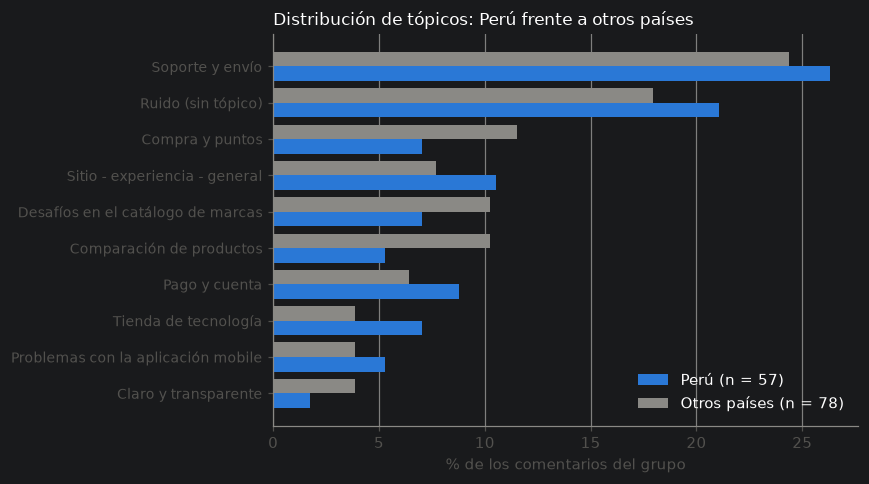

In [18]:
grupo = np.where(df["cliente_pais"] == "Peru", "Perú", "Otros países")
pct_pais = pd.crosstab(df["etiqueta"], grupo, normalize="columns").mul(100)

pct_pais = pct_pais.loc[pct_pais.mean(axis=1).sort_values().index]
fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(pct_pais))
ax.barh(y - 0.2, pct_pais["Perú"], height=0.4, color=AZUL, label=f"Perú (n = {(grupo == 'Perú').sum()})")
ax.barh(y + 0.2, pct_pais["Otros países"], height=0.4, color=GRIS,
        label=f"Otros países (n = {(grupo == 'Otros países').sum()})")
ax.set_yticks(y, pct_pais.index, fontsize=9)
ax.set_xlabel("% de los comentarios del grupo")
ax.set_title("Distribución de tópicos: Perú frente a otros países", loc="left", fontsize=11)
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## Discusión

- ¿Las etiquetas del LLM coinciden con los nombres que ustedes pondrían?
  ¿Qué cambiarían en el prompt (más documentos, más palabras, ejemplos)?
- Riesgos de usar un LLM: **costo** por documento, resultados que cambian
  entre ejecuciones (si se muestrea), **tópicos inventados** que no están en
  los datos y **envío de datos de clientes** a un servicio externo. ¿Cuáles
  evita un modelo local y cuáles no?
- Zero-shot frente a guiado: ¿cuál usarían si la empresa ya tiene una
  taxonomía de reclamos? ¿Y si quiere descubrir temas nuevos?
- Con 57 comentarios de Perú y 8 de Uruguay, ¿qué diferencias entre países son
  confiables?

In [ ]:
# Espacio para experimentar: cambien el PROMPT, la lista de tópicos esperados,
# zeroshot_min_similarity o las palabras semilla